In [14]:
import pandas as pd
df = pd.read_csv('insurance.csv')

# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# Show dataset shape (rows, columns)
print("Dataset shape (Rows, Columns):", df.shape)

# Show list of columns
print("Column Names:")
print(df.columns.tolist())

Dataset shape (Rows, Columns): (1338, 7)
Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [17]:
# Display dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
# Display statistical summary 
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:

print("--- Missing Values Count ---")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed! New dataset shape:", df.shape)

--- Missing Values Count ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Number of duplicate rows: 1
Duplicates removed! New dataset shape: (1337, 7)


In [ ]:

print("Before Preprocessing")
print(df.dtypes)

print("\n Sample Raw Data ")
df.head()

Before Preprocessing
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

 Sample Raw Data 


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

print("Categorical encoding completed!")

Categorical encoding completed!


In [ ]:

print("Data Types After Encoding")
print(df.dtypes)

print("Final Cleaned Dataset Preview ")
df.head()


Data Types After Encoding
age                   int64
bmi                 float64
children              int64
charges             float64
sex_male              int64
smoker_yes            int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object
Final Cleaned Dataset Preview 


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [ ]:
correlation = df.corr()['charges'].sort_values(ascending=False)

print("Correlation with Insurance Charges")
print(correlation)

print("KEY OBSERVATIONS:")
print("1. Smoking status has the strongest positive correlation with insurance charges.")
print("2. Age shows a moderate positive relationship; older individuals face higher premiums.")
print("3. BMI has a positive correlation, especially noticeable when combined with smoking.")

Correlation with Insurance Charges
charges             1.000000
smoker_yes          0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex_male            0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64
KEY OBSERVATIONS:
1. Smoking status has the strongest positive correlation with insurance charges.
2. Age shows a moderate positive relationship; older individuals face higher premiums.
3. BMI has a positive correlation, especially noticeable when combined with smoking.


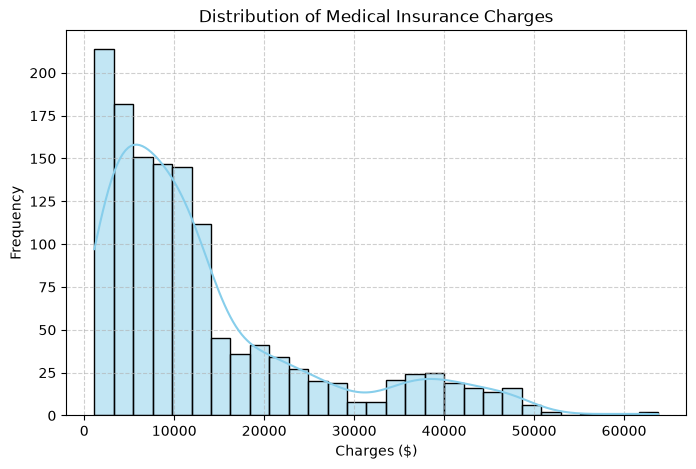

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True, color='skyblue')
plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

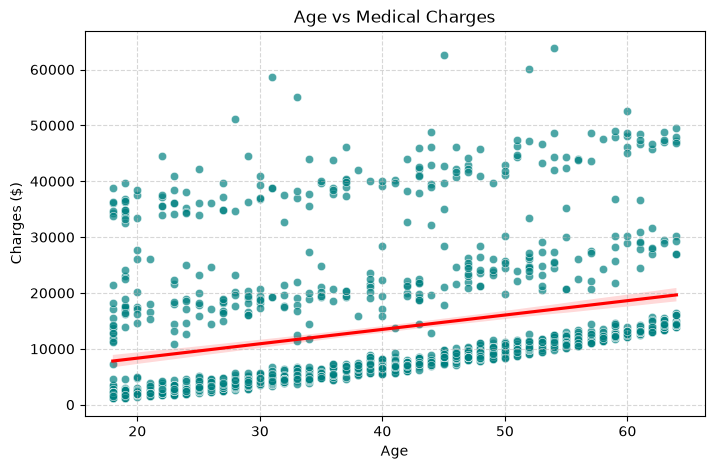

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['age'], y=df['charges'], alpha=0.7, color='teal')
sns.regplot(x=df['age'], y=df['charges'], scatter=False, color='red')

plt.title('Age vs Medical Charges')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

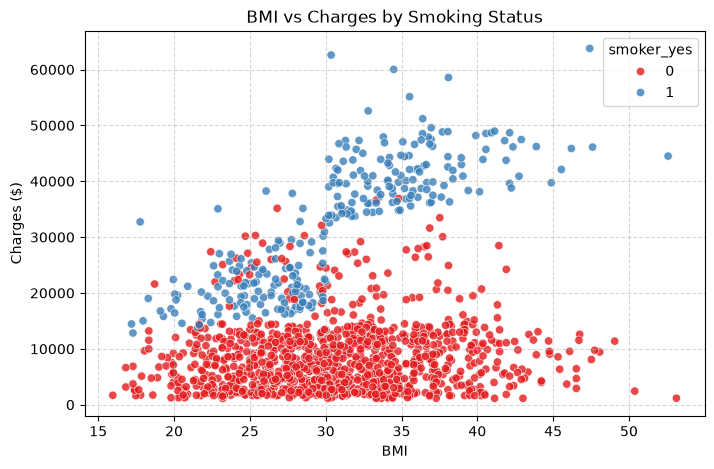

In [ ]:
smoker_col = 'smoker_yes' if 'smoker_yes' in df.columns else 'smoker'

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['bmi'], y=df['charges'], hue=df[smoker_col], palette='Set1', alpha=0.8)

plt.title('BMI vs Charges by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['charges'])
y = df['charges']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(" Data Splitting Complete ")
print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

 Data Splitting Complete 
Features shape (X): (1338, 6)
Target shape (y): (1338,)
Training set size: 1070 rows
Testing set size: 268 rows


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("--- Model Training Status ---")
print("Linear Regression model successfully trained!")
print(f"Model Intercept (b): {model.intercept_:.2f}")

--- Model Training Status ---
Linear Regression model successfully trained!
Model Intercept (b): -11931.22


In [ ]:
# Convert all text/categorical columns to numbers
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Reload raw data to ensure clean slate
df = pd.read_csv('insurance.csv')

# 2. Convert ALL text columns ('sex', 'smoker', 'region') into numbers
df = pd.get_dummies(df, drop_first=True, dtype=int)

# 3. Separate features (X) and target variable (y)
X = df.drop(columns=['charges'])
y = df['charges']

# 4. Perform Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Splitting Complete ---")
print("Features in X_train:", list(X_train.columns))
print(f"Training set size: {X_train.shape[0]} rows")

--- Data Splitting Complete ---
Features in X_train: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Training set size: 1070 rows


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

print(" Model Training Status ")
print("Linear Regression model successfully trained!")
print(f"Model Intercept (b): {model.intercept_:.2f}")

 Model Training Status 
Linear Regression model successfully trained!
Model Intercept (b): -11931.22


In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)


results_df = pd.DataFrame({
    'Actual Charges ($)': y_test.values[:5],
    'Predicted Charges ($)': y_pred[:5],
    'Difference ($)': y_test.values[:5] - y_pred[:5]
})

print(" Sample Predictions Preview ")
print(results_df.round(2))


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Basic Model Training Results ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")

 Sample Predictions Preview 
   Actual Charges ($)  Predicted Charges ($)  Difference ($)
0             9095.07                8969.55          125.52
1             5272.18                7068.75        -1796.57
2            29330.98               36858.41        -7527.43
3             9301.89                9454.68         -152.78
4            33750.29               26973.17         6777.12
--- Basic Model Training Results ---
Mean Absolute Error (MAE): $4181.19
Root Mean Squared Error (RMSE): $5796.28
R-squared Score (R²): 0.7836


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Phase 6: Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE)     : ${mae:.2f}")
print(f"Mean Squared Error (MSE)      : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Score (R²)          : {r2:.4f}")

--- Phase 6: Model Evaluation Metrics ---
Mean Absolute Error (MAE)     : $4181.19
Mean Squared Error (MSE)      : 33596915.85
Root Mean Squared Error (RMSE): $5796.28
R-squared Score (R²)          : 0.7836


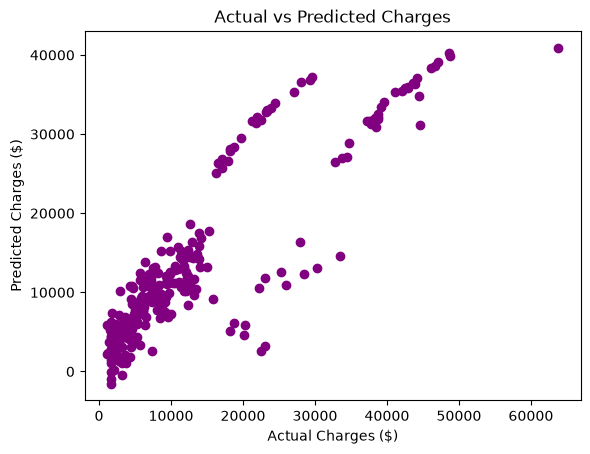

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color='purple')

plt.title('Actual vs Predicted Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')

# Display the chart
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install gradio


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import gradio as gr
import numpy as np
import pandas as pd

# 1. Define the prediction function using your trained model
def predict_insurance(age, sex, bmi, children, smoker, region):
    # Create DataFrame with raw user inputs
    input_data = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })
    
    # Encode categories into numeric columns
    encoded_input = pd.get_dummies(input_data, drop_first=True, dtype=int)
    
    # Align columns with X_train feature layout
    encoded_input = encoded_input.reindex(columns=X_train.columns, fill_value=0)
    
    # Generate prediction using the trained model
    prediction = model.predict(encoded_input)[0]
    
    # Ensure cost doesn't output negative values
    final_cost = max(0, prediction)
    
    return f"${final_cost:,.2f}"

# 2. Build the UI Interface
interface = gr.Interface(
    fn=predict_insurance,
    inputs=[
        gr.Slider(18, 100, step=1, value=30, label="Age"),
        gr.Dropdown(["male", "female"], value="female", label="Gender"),
        gr.Number(value=25.0, label="BMI"),
        gr.Slider(0, 5, step=1, value=0, label="Number of Children"),
        gr.Radio(["yes", "no"], value="no", label="Smoker"),
        gr.Dropdown(["southwest", "southeast", "northwest", "northeast"], value="southeast", label="Region")
    ],
    outputs=gr.Textbox(label="Estimated Medical Insurance Cost"),
    title="Medical Insurance Cost Predictor",
    description="Enter customer details to predict annual medical insurance charges using the trained Multiple Linear Regression model."
)

# 3. Launch inline in Jupyter Notebook
interface.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "c:\Users\YC\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\queueing.py", line 848, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "c:\Users\YC\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\route_utils.py", line 417, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<12 lines>...
    )
    ^
  File "c:\Users\YC\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\blocks.py", line 2698, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<9 lines>...
    )
    ^
  File "c:\Users\YC\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\blocks.py", line 1963, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^

In [1]:
import pandas as pd
import numpy as np

# Load scikit-learn modules
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load fresh dataset
df = pd.read_csv('insurance.csv')
print("Imports loaded and dataset read successfully!")

Imports loaded and dataset read successfully!


In [2]:
# Convert text columns to numerical indicators
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

# Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

# Perform Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully processed and split!")
print(f"Features in X_train: {list(X_train.columns)}")

Data successfully processed and split!
Features in X_train: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Fit the Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Predict on test set
y_pred = model.predict(X_test)

# 3. Print Evaluation Metrics for Phase 6 proof
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Phase 6: Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE)     : ${mae:.2f}")
print(f"Mean Squared Error (MSE)      : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Score (R²)          : {r2:.4f}")

--- Phase 6: Model Evaluation Metrics ---
Mean Absolute Error (MAE)     : $4181.19
Mean Squared Error (MSE)      : 33596915.85
Root Mean Squared Error (RMSE): $5796.28
R-squared Score (R²)          : 0.7836


In [5]:
import gradio as gr

def predict_insurance(age, sex, bmi, children, smoker, region):
    input_data = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })
    
    # Process categorical entries dynamically
    encoded_input = pd.get_dummies(input_data, drop_first=True, dtype=int)
    encoded_input = encoded_input.reindex(columns=X_train.columns, fill_value=0)
    
    # Predict
    prediction = model.predict(encoded_input)[0]
    final_cost = max(0, prediction)
    
    return f"${final_cost:,.2f}"

# Interface design
interface = gr.Interface(
    fn=predict_insurance,
    inputs=[
        gr.Slider(18, 100, step=1, value=30, label="Age"),
        gr.Dropdown(["male", "female"], value="female", label="Gender"),
        gr.Number(value=25.0, label="BMI"),
        gr.Slider(0, 5, step=1, value=0, label="Number of Children"),
        gr.Radio(["yes", "no"], value="no", label="Smoker"),
        gr.Dropdown(["southwest", "southeast", "northwest", "northeast"], value="southeast", label="Region")
    ],
    outputs=gr.Textbox(label="Estimated Medical Insurance Cost"),
    title="Medical Insurance Cost Predictor"
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://f44f1917a83bec1157.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
